In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")

In [2]:
BASE_DIR = Path().resolve().parent
DATA_PATH = BASE_DIR / "data" / "email_access_data.csv"

df = pd.read_csv(DATA_PATH)
df.head()

,text,label
0,Access granted to Analytics Server.,approved
1,Manager approval not received for HR Portal.,rejected
2,Unable to process your request for Finance Das...,manual
3,Request could not be understood.,manual
4,Request could not be understood.,manual


In [3]:
print("Shape:", df.shape)
df.info()

Shape: (498, 2)
<class 'pandas.DataFrame'>
RangeIndex: 498 entries, 0 to 497
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    498 non-null    str  
 1   label   498 non-null    str  
dtypes: str(2)
memory usage: 7.9 KB


In [4]:
df.isnull().sum()

text     0
label    0
dtype: int64

In [5]:
df["label"].value_counts()

label
approved    166
rejected    166
manual      166
Name: count, dtype: int64

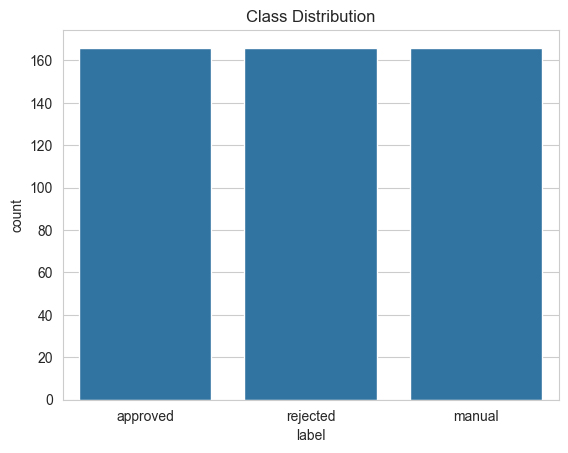

In [6]:
plt.figure()
sns.countplot(data=df, x="label")
plt.title("Class Distribution")
plt.show()

In [7]:
df["text_length"] = df["text"].apply(lambda x: len(x.split()))
df["text_length"].describe()

count    498.000000
mean       6.108434
std        1.761507
min        3.000000
25%        5.000000
50%        6.000000
75%        8.000000
max        9.000000
Name: text_length, dtype: float64

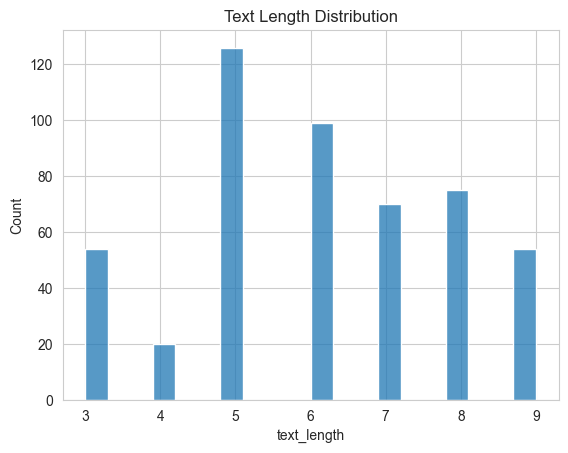

In [8]:
plt.figure()
sns.histplot(df["text_length"], bins=20)
plt.title("Text Length Distribution")
plt.show()

In [9]:
for label in df["label"].unique():
    print(f"\n--- {label.upper()} ---")
    print(df[df["label"] == label]["text"].sample(3).values)


--- APPROVED ---
<StringArray>
[    'You can now login to Analytics Server.',
    'You can now login to Finance Dashboard.',
 'Permission approved for Finance Dashboard.']
Length: 3, dtype: str

--- REJECTED ---
<StringArray>
['Access denied due to missing approval.',
       'Request rejected for CRM System.',
 'Access denied due to missing approval.']
Length: 3, dtype: str

--- MANUAL ---
<StringArray>
[               'Please contact administrator.',
 'Manual review required for Analytics Server.',
             'Request could not be understood.']
Length: 3, dtype: str


In [10]:
df.duplicated().sum()

np.int64(439)